# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
#Type your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings


sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
#Type your code here
file_path = 'namadataset_raw/phishing_site_urls.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset berhasil dimuat!")
    print(f"Total baris dan kolom: {df.shape}\n")


    display(df.head())
except FileNotFoundError:
    print("Gagal: File CSV tidak ditemukan.")

Dataset berhasil dimuat secara optimal!
Total baris dan kolom: (549346, 2)



,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB

--- Jumlah Nilai Kosong per Kolom ---
URL      0
Label    0
dtype: int64


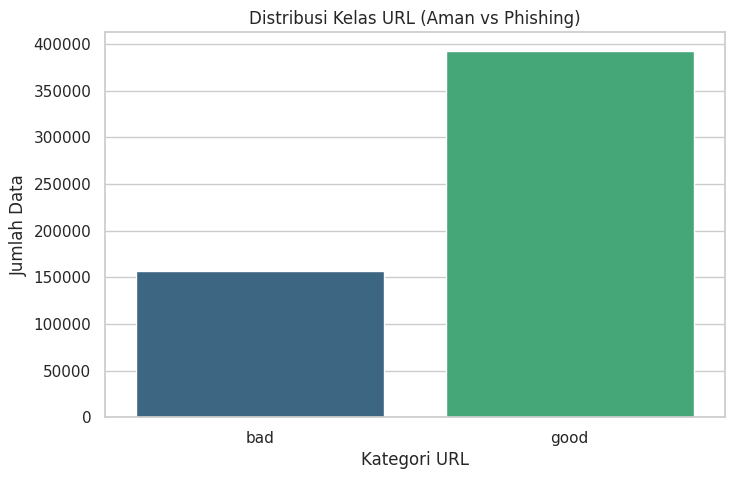

In [5]:
#Type your code here
# 1. Menampilkan informasi umum (tipe data masing-masing kolom)
print("--- Informasi Dataset ---")
df.info()

# 2. Mengecek apakah ada baris data yang kosong
print("\n--- Jumlah Nilai Kosong per Kolom ---")
print(df.isnull().sum())

# 3. Visualisasi distribusi target kelas
# Catatan: Kolom target di dataset ini bernama 'Label'
plt.figure(figsize=(8, 5))
sns.countplot(x='Label', data=df, palette='viridis')
plt.title('Distribusi Kelas URL (Aman vs Phishing)')
plt.xlabel('Kategori URL')
plt.ylabel('Jumlah Data')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
import os
from sklearn.preprocessing import LabelEncoder

print(f"Total data awal: {df.shape[0]} baris")

# 1. Menghapus Data Duplikat
# Data URL hasil scraping sering kali memiliki banyak duplikat
df_clean = df.drop_duplicates().copy()
print(f"Total data setelah hapus duplikat: {df_clean.shape[0]} baris")

# 2. Menangani Data Kosong (Missing Values)
# Memastikan tidak ada baris yang kehilangan nilai URL atau Label-nya
df_clean = df_clean.dropna()
print(f"Total data setelah hapus nilai kosong: {df_clean.shape[0]} baris")

# 3. Encoding Data Kategorikal
# Mengubah kolom 'Label' yang berisi teks (misal: 'good' dan 'bad') menjadi angka (0 dan 1)
encoder = LabelEncoder()
df_clean['Label'] = encoder.fit_transform(df_clean['Label'])

print("\n--- Sampel Data Setelah Preprocessing ---")
display(df_clean.head())

# 4. Menyimpan Dataset Bersih
# Membuat struktur folder sesuai ketentuan Kriteria 1 untuk menyimpan artefak data
output_dir = 'namadataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, 'dataset_clean.csv')
df_clean.to_csv(output_file, index=False)

print(f"\n[SUKSES] Dataset siap latih telah disimpan secara lokal di: {output_file}")

Total data awal: 549346 baris
Total data setelah hapus duplikat: 507196 baris
Total data setelah hapus nilai kosong: 507196 baris

--- Sampel Data Setelah Preprocessing ---


,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,0
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,0
3,mail.printakid.com/www.online.americanexpress....,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,0



[SUKSES] Dataset siap latih telah disimpan secara lokal di: namadataset_preprocessing/dataset_clean.csv
